# BIS568 Final Project — AKI Model Interpretability

This notebook presents the interpretability and explainability analysis for the AKI early-prediction project.

---
## Section 1: Setup and Data Preparation

We use the cleaned cohort file, rebuild the same random-forest pipeline used in
model development, and then apply post-hoc explainability methods on the held-out
test set.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from IPython.display import display
from lime.lime_tabular import LimeTabularExplainer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.model_selection import GroupShuffleSplit

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
plt.rcParams["figure.dpi"] = 100
sns.set_style("whitegrid")

In [2]:
df_raw = pd.read_csv("outputs/mimic_aki_cohort_cleaned.csv")

target_col = "future_aki_24h"
id_cols = ["subject_id", "hadm_id", "stay_id"]
time_cols = [
    "icu_intime",
    "anchor_time",
    "obs_window_start",
    "obs_window_end",
    "pred_window_start",
    "pred_window_end",
]

drop_cols = id_cols + time_cols + [target_col]
X = df_raw.drop(columns=[c for c in drop_cols if c in df_raw.columns]).copy()
y = df_raw[target_col].astype(int).copy()
groups = df_raw["subject_id"].copy()

cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

def safe_div(num, den):
    out = num / den.replace(0, np.nan)
    return out.replace([np.inf, -np.inf], np.nan)

if {"bun_last_6h", "creatinine_last_6h"}.issubset(X.columns):
    X["bun_creatinine_ratio_last_6h"] = safe_div(X["bun_last_6h"], X["creatinine_last_6h"])
if {"sbp_last_6h", "dbp_last_6h"}.issubset(X.columns):
    X["pulse_pressure_last_6h"] = X["sbp_last_6h"] - X["dbp_last_6h"]
if {"heart_rate_last_6h", "sbp_last_6h"}.issubset(X.columns):
    X["shock_index_last_6h"] = safe_div(X["heart_rate_last_6h"], X["sbp_last_6h"])
if {"urine_total_6h", "weight_used_for_uo_norm"}.issubset(X.columns):
    X["urine_ml_per_kg_6h"] = safe_div(X["urine_total_6h"], X["weight_used_for_uo_norm"])
if {"creatinine_last_6h", "creatinine_first_6h"}.issubset(X.columns):
    X["creatinine_change_6h"] = X["creatinine_last_6h"] - X["creatinine_first_6h"]

X = pd.get_dummies(X, columns=cat_cols, drop_first=True, dtype=float)

missing_rate = X.isna().mean()
miss_ind_cols = missing_rate[missing_rate >= 0.05].index.tolist()
if miss_ind_cols:
    miss_ind_df = pd.DataFrame(
        {f"{col}_is_missing": X[col].isna().astype(int) for col in miss_ind_cols}
    )
    X = pd.concat([X, miss_ind_df], axis=1)

gss1 = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_STATE)
idx_trainval, idx_test = next(gss1.split(X, y, groups))

X_trainval, y_trainval = X.iloc[idx_trainval], y.iloc[idx_trainval]
groups_trainval = groups.iloc[idx_trainval]
X_test, y_test = X.iloc[idx_test], y.iloc[idx_test]

gss2 = GroupShuffleSplit(n_splits=1, test_size=0.125, random_state=RANDOM_STATE)
idx_train, idx_val = next(gss2.split(X_trainval, y_trainval, groups_trainval))

X_train, y_train = X_trainval.iloc[idx_train], y_trainval.iloc[idx_train]
train_medians = X_train.median(numeric_only=True)
X_train = X_train.fillna(train_medians)
X_test = X_test.fillna(train_medians)

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=RANDOM_STATE,
)
rf.fit(X_train, y_train)

rf_test_prob = rf.predict_proba(X_test)[:, 1]
print(f"Train shape: {X_train.shape}")
print(f"Test shape:  {X_test.shape}")
print(f"Test AUROC:  {roc_auc_score(y_test, rf_test_prob):.4f}")
print(f"Test PR-AUC: {average_precision_score(y_test, rf_test_prob):.4f}")

Train shape: (20491, 298)
Test shape:  (5855, 298)
Test AUROC:  0.7281
Test PR-AUC: 0.7964


---
## Section 2: SHAP Global Explanations

We use **SHAP TreeExplainer** to quantify how much each feature contributes to the
random forest's AKI-risk predictions on the test set. The goal is to identify which
early ICU signals drive the model most strongly at the population level.

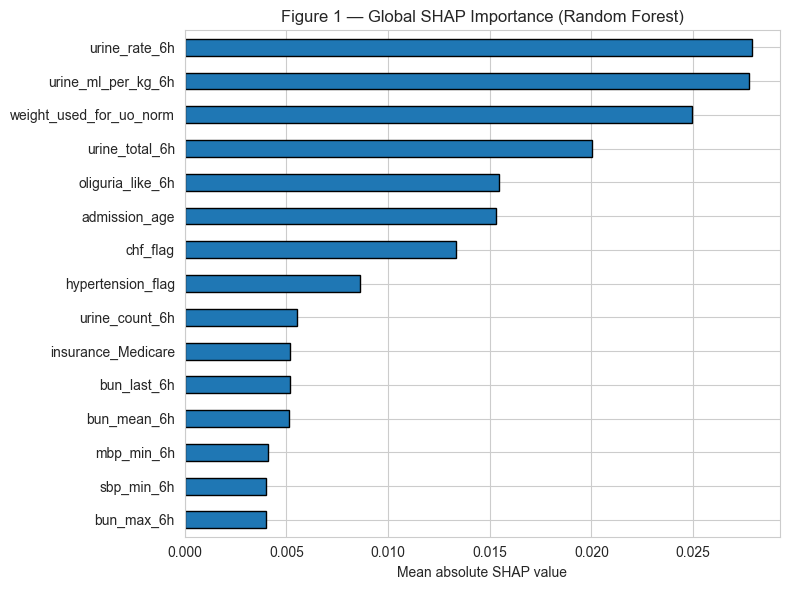

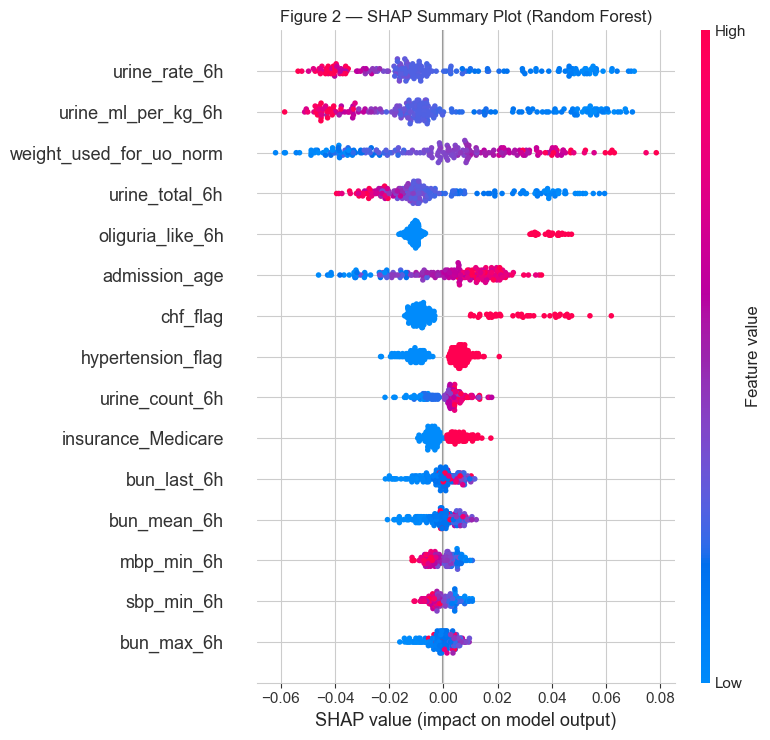

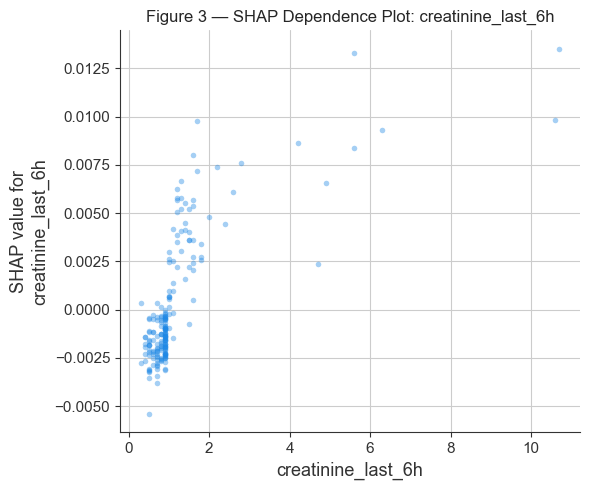

,feature,mean_abs_shap
0,urine_rate_6h,0.0279
1,urine_ml_per_kg_6h,0.0277
2,weight_used_for_uo_norm,0.0249
3,urine_total_6h,0.0200
4,oliguria_like_6h,0.0155
5,admission_age,0.0153
6,chf_flag,0.0133
7,hypertension_flag,0.0086
8,urine_count_6h,0.0055
9,insurance_Medicare,0.0052


In [3]:
def extract_positive_class_shap(shap_values):
    if isinstance(shap_values, list):
        return shap_values[1] if len(shap_values) > 1 else shap_values[0]
    shap_values = np.asarray(shap_values)
    if shap_values.ndim == 3:
        if shap_values.shape[-1] > 1:
            return shap_values[:, :, 1]
        return shap_values[:, :, 0]
    return shap_values

n_shap = min(200, len(X_test))
X_test_shap = X_test.sample(n=n_shap, random_state=RANDOM_STATE).copy()

rf_explainer = shap.TreeExplainer(rf)
rf_shap = extract_positive_class_shap(rf_explainer.shap_values(X_test_shap))

mean_abs_shap = (
    pd.Series(np.abs(rf_shap).mean(axis=0), index=X_test_shap.columns)
    .sort_values(ascending=False)
)
top_shap = mean_abs_shap.head(15)

fig, ax = plt.subplots(figsize=(8, 6))
top_shap.sort_values().plot(kind="barh", ax=ax, color="#1f77b4", edgecolor="black")
ax.set_xlabel("Mean absolute SHAP value")
ax.set_title("Figure 1 — Global SHAP Importance (Random Forest)")
plt.tight_layout()
plt.savefig("outputs/interpretability_shap_bar.png", dpi=150, bbox_inches="tight")
plt.show()

shap.summary_plot(rf_shap, X_test_shap, max_display=15, show=False)
plt.title("Figure 2 — SHAP Summary Plot (Random Forest)")
plt.tight_layout()
plt.savefig("outputs/interpretability_shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()

preferred_dep_features = [
    "creatinine_last_6h",
    "urine_rate_6h",
    "bun_creatinine_ratio_last_6h",
    "creatinine_change_6h",
    "oliguria_like_6h",
    "admission_age",
]
dependence_feature = next(
    (f for f in preferred_dep_features if f in X_test_shap.columns),
    top_shap.index[0],
)

shap.dependence_plot(
    dependence_feature,
    rf_shap,
    X_test_shap,
    interaction_index=None,
    alpha=0.4,
    dot_size=16,
    show=False,
)
plt.title(f"Figure 3 — SHAP Dependence Plot: {dependence_feature}")
plt.tight_layout()
plt.savefig("outputs/interpretability_shap_dependence.png", dpi=150, bbox_inches="tight")
plt.show()

shap_global_table = top_shap.reset_index()
shap_global_table.columns = ["feature", "mean_abs_shap"]
display(shap_global_table.round(4))

### SHAP Interpretation

We applied SHAP to improve the interpretability of the random forest model and to identify the main drivers of AKI prediction within 24 hours. The global SHAP importance plot showed that urine-output-related variables were the most influential predictors, including urine rate over 6 hours, urine output normalized by body weight, total urine output, and an oliguria-like indicator. Other important features included admission age, congestive heart failure, hypertension, BUN-related measures, and minimum blood pressure variables. Compared with a standard feature-importance ranking, the SHAP summary plot is more informative because it shows not only which features matter, but also whether higher or lower feature values push predictions toward higher or lower AKI risk. In our results, lower urine output values generally pushed predictions toward higher AKI risk, whereas higher urine output values pushed predictions toward lower risk. This pattern is clinically plausible because reduced urine output is a key early sign of kidney dysfunction. Older age and cardiovascular comorbidities also contributed positively to predicted risk, suggesting that the model incorporates baseline patient vulnerability in addition to short-term physiologic status. Finally, the dependence plot for creatinine showed that higher recent creatinine levels were generally associated with more positive SHAP values, indicating an increased contribution to AKI risk prediction. Overall, the SHAP results suggest that the model relies on clinically meaningful features related to renal function, fluid balance, and hemodynamic instability, which improves transparency and supports the credibility of the model.

---
## Section 3: LIME Local Explanations

We next use **LIME** to explain individual predictions. One high-risk true-positive
patient and one low-risk true-negative patient are selected from the test set so the
local logic of the model can be compared across contrasting examples.

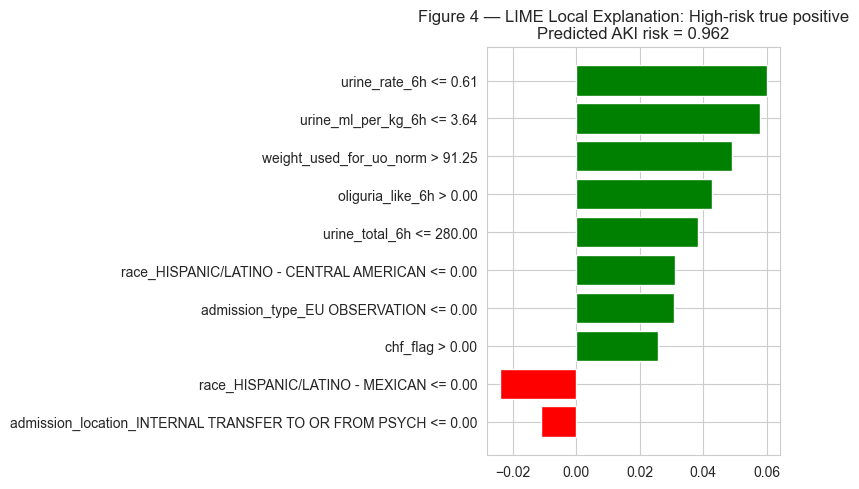

High-risk true positive
Test row index: 2464
Predicted AKI risk: 0.962


,feature_rule,weight
0,urine_rate_6h <= 0.61,0.0599
1,urine_ml_per_kg_6h <= 3.64,0.0580
2,weight_used_for_uo_norm > 91.25,0.0489
3,oliguria_like_6h > 0.00,0.0428
4,urine_total_6h <= 280.00,0.0384
5,race_HISPANIC/LATINO - CENTRAL AMERICAN <= 0.00,0.0312
6,admission_type_EU OBSERVATION <= 0.00,0.0307
7,chf_flag > 0.00,0.0257
8,race_HISPANIC/LATINO - MEXICAN <= 0.00,-0.0239
9,admission_location_INTERNAL TRANSFER TO OR FRO...,-0.0111


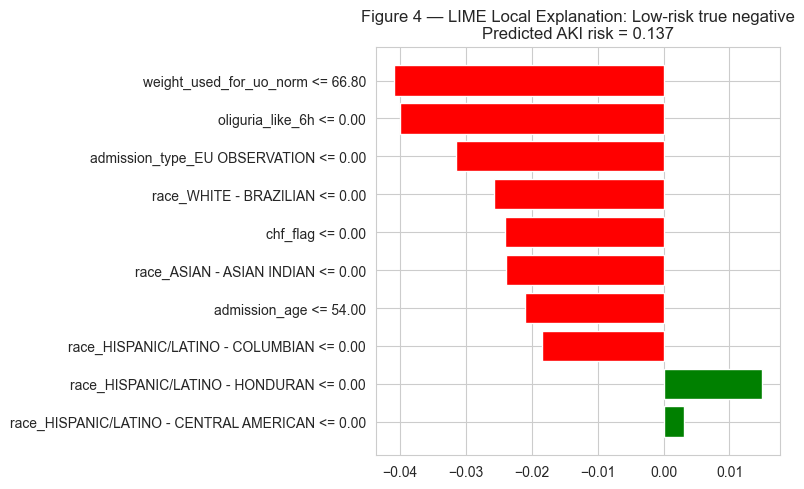

Low-risk true negative
Test row index: 25410
Predicted AKI risk: 0.137


,feature_rule,weight
0,weight_used_for_uo_norm <= 66.80,-0.0409
1,oliguria_like_6h <= 0.00,-0.0399
2,admission_type_EU OBSERVATION <= 0.00,-0.0315
3,race_WHITE - BRAZILIAN <= 0.00,-0.0257
4,chf_flag <= 0.00,-0.0240
5,race_ASIAN - ASIAN INDIAN <= 0.00,-0.0239
6,admission_age <= 54.00,-0.0210
7,race_HISPANIC/LATINO - COLUMBIAN <= 0.00,-0.0184
8,race_HISPANIC/LATINO - HONDURAN <= 0.00,0.0149
9,race_HISPANIC/LATINO - CENTRAL AMERICAN <= 0.00,0.0031


In [4]:
case_frame = pd.DataFrame({"y_true": y_test.values, "rf_prob": rf_test_prob}, index=X_test.index)
tp_idx = case_frame[case_frame["y_true"] == 1]["rf_prob"].sort_values(ascending=False).index[0]
tn_idx = case_frame[case_frame["y_true"] == 0]["rf_prob"].sort_values(ascending=True).index[0]

lime_explainer = LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns.tolist(),
    class_names=["No AKI", "AKI"],
    mode="classification",
    discretize_continuous=True,
    random_state=RANDOM_STATE,
)

def rf_predict_proba_for_lime(arr):
    arr_df = pd.DataFrame(arr, columns=X_train.columns)
    return rf.predict_proba(arr_df)

selected_cases = [
    (tp_idx, "High-risk true positive"),
    (tn_idx, "Low-risk true negative"),
]

for case_idx, case_label in selected_cases:
    exp = lime_explainer.explain_instance(
        X_test.loc[case_idx].values,
        rf_predict_proba_for_lime,
        num_features=10,
    )

    fig = exp.as_pyplot_figure()
    fig.set_size_inches(8, 5)
    plt.title(
        f"Figure 4 — LIME Local Explanation: {case_label}\n"
        f"Predicted AKI risk = {case_frame.loc[case_idx, 'rf_prob']:.3f}"
    )
    plt.tight_layout()
    file_stub = case_label.lower().replace(" ", "_")
    plt.savefig(
        f"outputs/interpretability_lime_{file_stub}.png",
        dpi=150,
        bbox_inches="tight",
    )
    plt.show()

    local_df = pd.DataFrame(exp.as_list(), columns=["feature_rule", "weight"])
    local_df["abs_weight"] = local_df["weight"].abs()
    local_df = local_df.sort_values("abs_weight", ascending=False).drop(columns="abs_weight")
    print(case_label)
    print(f"Test row index: {case_idx}")
    print(f"Predicted AKI risk: {case_frame.loc[case_idx, 'rf_prob']:.3f}")
    display(local_df.head(10).round(4))

### LIME Interpretation

We used LIME to provide local explanations for individual patient-level predictions from the random forest model. For the high-risk true positive case, the model predicted an AKI risk of 0.962. LIME showed that this prediction was primarily driven by low urine-output-related features, including low urine rate over 6 hours, low urine output normalized by body weight, low total urine output, and the presence of an oliguria-like pattern. Congestive heart failure also contributed positively to the predicted risk. These findings are clinically plausible and consistent with the global SHAP results.

For the low-risk true negative case, the model predicted an AKI risk of 0.137. In this example, the absence of an oliguria-like signal, absence of congestive heart failure, and younger age contributed to a lower predicted risk. Compared with the high-risk case, this patient did not exhibit the same strong urine-output-related warning signs. Together, these local explanations show how the model distinguishes high-risk from low-risk patients using clinically meaningful features, thereby improving transparency at the individual case level. Some one-hot encoded demographic or administrative indicators also appeared in the local explanations, but these should be interpreted more cautiously than the physiologic urine-output-related features.

---
## Section 4: Integrated Interpretation of SHAP and LIME
Because SHAP and LIME address different levels of explanation, using both methods provides a more complete understanding of model behavior. Together, SHAP and LIME improved the interpretability of the random forest model at both the cohort and individual-patient levels. SHAP provided global interpretability by identifying the most influential predictors across the full dataset, while LIME provided local interpretability by explaining why specific patients were assigned high-risk or low-risk predictions. Compared with standard feature importance rankings, the SHAP summary plot offered more informative interpretation because it showed not only which features mattered, but also the direction and distribution of their effects on model output. Across the SHAP analyses, multiple urine-output-related variables consistently appeared among the top predictors, suggesting that the model repeatedly relied on the same underlying physiologic signal rather than a single unstable feature. The dependence plot further added value by showing the shape of the feature effect, suggesting that the relationship between creatinine and predicted AKI risk was not strictly linear. We included both a high-risk true positive and a low-risk true negative LIME example to show how the model distinguishes between patients with and without strong AKI warning signs at the individual level. For stakeholders, these explanations improve transparency, help assess whether the model is relying on clinically reasonable predictors, and may increase trust in the model as a clinical decision-support tool. However, these explainability methods describe model behavior rather than causality, and some correlated urine-output-related features or one-hot encoded demographic and administrative variables should be interpreted cautiously.